# 1. Import & Config

In [1]:
import sys, os, json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
# from scipy.stats import gaussian_kde

from config import InferenceConfig, DDPMTransformerConfig
from utils import setup_logging, setup_random_seed, load_variant, inverse_x, simulate_mc_gbm
from utils.paths import PROCESSED_DIR, EXPERIMENTS_DIR

logger = setup_logging()
logger.info("✓ Imports OK")

2026-05-28 03:46:55,082 - utils.setup - INFO - Logger is set up.
2026-05-28 03:46:55,084 - utils.setup - INFO - ✓ Imports OK


## 1.1 Config

In [2]:
inf_cfg = InferenceConfig(
    name              = "v3_portfolio_01",
    group             = "",
    description       = "Portfolio analysis from simulation outputs",

    processed_dir     = Path(PROCESSED_DIR),
    experiments_dir   = Path(EXPERIMENTS_DIR),

    experiment_name   = "v1_trial04_ddpm_warmup-cosine_w20_d20_seqWA_featDC_robust_standard",
    simulation_name   = "demo_sim_01",
    checkpoint_file   = "epoch_1000.pt",

    num_simulations   = 100,
    random_seed       = 42,
)

setup_random_seed(inf_cfg.random_seed)

print("=" * 60)
print("  V3-4 PORTFOLIO")
print("=" * 60)
print(f"  Experiment      : {inf_cfg.experiment_name}")
print(f"  Simulation      : {inf_cfg.simulation_name}")
print(f"  Simulation dir  : {inf_cfg.simulation_dir}")
print("=" * 60)

  V3-4 PORTFOLIO
  Experiment      : v1_trial04_ddpm_warmup-cosine_w20_d20_seqWA_featDC_robust_standard
  Simulation      : demo_sim_01
  Simulation dir  : /home/narodom.y@FUSION.LAB/research/02_experiments/v1_trial04_ddpm_warmup-cosine_w20_d20_seqWA_featDC_robust_standard/simulations/demo_sim_01


# 2. Load Simulation Data

## 2.1 SimulationDataset

โหลดจาก `.npz` ที่ save ไว้ใน `sim_dir` ของ V3-3  
แต่ละ file = 1 test window ประกอบด้วย:

| key | shape | description |
|---|---|---|
| `x_gen` | `(N, A, W, D, C)` | generated log-returns (N sims) |
| `x_real` | `(A, W, D, C)` | real log-returns |
| `log_returns` | `(N, A, W, C)` | decoded log-returns |
| `prices` | `(N, A, W, C)` | decoded prices |
| `init_price` | `(A,)` | initial price ของ window |
| `dates` | `(W,)` | timestamps ของแต่ละ window step |
| `init_date` | scalar | timestamp เริ่มต้น window |
| `ohlcv` | `(A, W, D, C)` | raw OHLCV real data |

In [3]:
import glob

class SimulationDataset(Dataset):
    def __init__(self, sim_dir: Path):
        self.sim_dir = Path(sim_dir)
        with open(self.sim_dir / "meta.json") as f:
            self.meta = json.load(f)

        # นับจาก file จริง ไม่เชื่อ meta
        self.n = len(sorted(self.sim_dir.glob("batch_*.npz")))

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        raw = np.load(self.sim_dir / f"batch_{idx:03d}.npz")
        return {k: raw[k] for k in raw.files}

    def __repr__(self):
        return (f"SimulationDataset(n_windows={self.n}, "
                f"n_sims={self.meta['num_simulations']}, "
                f"symbols={len(self.meta['symbols'])})")

## 2.2 Load & Inspect

In [4]:
sim_dir = inf_cfg.simulation_dir
dataset = SimulationDataset(sim_dir)
print(dataset)

# meta summary
meta = dataset.meta
SYMBOLS     = meta["symbols"]
N_SIMS      = meta["num_simulations"]
# N_WINDOWS   = meta["n_windows"]
N_WINDOWS = dataset.n
N_ASSETS    = len(SYMBOLS)

print(f"\n  symbols      : {SYMBOLS}")
print(f"  n_windows    : {N_WINDOWS}")
print(f"  n_sims       : {N_SIMS}")
print(f"  created_at   : {meta['created_at']}")

SimulationDataset(n_windows=5, n_sims=100, symbols=16)

  symbols      : ['AAPL', 'AMZN', 'CAT', 'EEM', 'GOOGL', 'JNJ', 'JPM', 'KO', 'META', 'MSFT', 'NVDA', 'SPY', 'TLT', 'TSLA', 'GLD', 'XOM']
  n_windows    : 5
  n_sims       : 100
  created_at   : 2026-05-27T04:16:18.686085+00:00


## 2.3 Shape Check

In [5]:
# peek at first window
sample = dataset[0]

print(f"{'key':<16} {'shape':<30} dtype")
print("─" * 60)
for k, v in sample.items():
    arr = np.array(v)
    print(f"  {k:<14} {str(arr.shape):<30} {arr.dtype}")

key              shape                          dtype
────────────────────────────────────────────────────────────
  x_gen          (100, 16, 20, 20, 4)           float32
  x_real         (16, 20, 20, 4)                float32
  cond           (16, 20, 11)                   float32
  init_price     (16,)                          float32
  init_date      ()                             int64
  dates          (20,)                          int64
  ohlcv          (16, 20, 4)                    float32
  log_returns    (100, 16, 20, 20, 4)           float32
  prices         (100, 16, 20, 20)              float32


## 2.4 Load All Windows into Memory

In [6]:
# โหลดทั้งหมดเข้า memory (สะดวกถ้า dataset ไม่ใหญ่มาก)
# ถ้า dataset ใหญ่ → ใช้ DataLoader แทน

all_windows = [dataset[i] for i in range(N_WINDOWS)]
print(f"  ✓ loaded {len(all_windows)} windows")

# ── ตัวอย่าง: ใช้ DataLoader ─────────────────────────────────────────
# loader = DataLoader(dataset, batch_size=1, shuffle=False)
# for batch in loader:
#     x_gen      = batch["x_gen"]      # (1, N, A, W, D, C)
#     prices     = batch["prices"]     # (1, N, A, W, C)
#     init_price = batch["init_price"] # (1, A)
#     ...

# ── ตัวอย่าง: stack arrays ────────────────────────────────────────────
# prices shape per window: (N, A, W, C) → stack → (T_windows, N, A, W, C)
all_prices     = np.stack([w["prices"]      for w in all_windows])  # (T, N, A, W, C)
all_log_ret    = np.stack([w["log_returns"] for w in all_windows])  # (T, N, A, W, C)
all_init_price = np.stack([w["init_price"]  for w in all_windows])  # (T, A)
all_dates      = np.stack([w["dates"]       for w in all_windows])  # (T, W)

print(f"  all_prices     : {all_prices.shape}")
print(f"  all_log_ret    : {all_log_ret.shape}")
print(f"  all_init_price : {all_init_price.shape}")
print(f"  all_dates      : {all_dates.shape}")

  ✓ loaded 5 windows
  all_prices     : (5, 100, 16, 20, 20)
  all_log_ret    : (5, 100, 16, 20, 20, 4)
  all_init_price : (5, 16)
  all_dates      : (5, 20)


In [7]:
for w in all_windows:
    print(w["prices"].shape)

(100, 16, 20, 20)
(100, 16, 20, 20)
(100, 16, 20, 20)
(100, 16, 20, 20)
(100, 16, 20, 20)


## 2.5 Load Feature Store

In [8]:
feature_name, feature_variant = inf_cfg.load_feature_store_info()
_, scalers = load_variant(inf_cfg.processed_dir, feature_name, feature_variant)
x_scaler = scalers["x"]

print(f"  feature_store : {feature_name} / {feature_variant}")
print(f"  ✓ x_scaler loaded")

  feature_store : v1_trial04_w20_d20_asset16 / robust_standard
  ✓ x_scaler loaded


In [9]:
from entities import Portfolio  # ปรับ import ตาม path จริง

CLOSE_IDX = 3  # ohlcv channel: 0=open, 1=high, 2=low, 3=close

# ── gt_returns & gt_prices ────────────────────────────────────────────
# ohlcv shape per window: (A, W, D, C) → เอา close channel
# all_windows[t]["ohlcv"] : (A, W, D=20, C=4) → close: (A, W, D)
# flatten W×D → (A, W*D) → transpose → (W*D, A) = (n_periods, A)

def prepare_gt(windows: list[dict], c_idx: int = 0):
    gt_price_list = []
    for w in windows:
        ohlcv = w["ohlcv"]              # (A, W, C) — C=4: o/h/l/c
        close = ohlcv[:, :, c_idx]     # (A, W)
        gt_price_list.append(close.T)  # (W, A)

    gt_prices  = np.concatenate(gt_price_list, axis=0)
    gt_returns = np.diff(np.log(gt_prices + 1e-8), axis=0)
    gt_prices  = gt_prices[1:]
    return gt_returns, gt_prices


# ── mc_returns ────────────────────────────────────────────────────────
# log_returns shape per window: (N, A, W, D, C) → close: (N, A, W, D)
# flatten W×D → (N, A, W*D) → transpose axes → (N, W*D, A) = (N, n_periods, A)

def prepare_mc(windows: list[dict], d_idx: int = 0, c_idx: int = 0):
    mc_list = []
    for w in windows:
        lr = w["log_returns"]           # (N, A, W, D, C)
        step = lr[:, :, :, d_idx, c_idx]  # (N, A, W) — เอาแค่ D=0, C=0
        flat = step.transpose(0, 2, 1)    # (N, W, A) = (N, n_periods, A)
        mc_list.append(flat)

    return np.concatenate(mc_list, axis=1)  # (N, n_periods_total, A)


gt_returns, gt_prices = prepare_gt(all_windows)
mc_returns            = prepare_mc(all_windows)

print(f"  gt_returns  : {gt_returns.shape}   (n_periods, n_assets)")
print(f"  gt_prices   : {gt_prices.shape}   (n_periods, n_assets)")
print(f"  mc_returns  : {mc_returns.shape}  (n_sims, n_periods, n_assets)")

  gt_returns  : (99, 16)   (n_periods, n_assets)
  gt_prices   : (99, 16)   (n_periods, n_assets)
  mc_returns  : (100, 100, 16)  (n_sims, n_periods, n_assets)


In [10]:
# เช็คว่า window ไหน / asset ไหน ที่มีปัญหา
print(f"gt_returns shape: {gt_returns.shape}")
print(f"mc_returns shape: {mc_returns.shape}")
print()

# 1. หา asset ที่ variance = 0 หรือ near-zero ใน gt
gt_var = np.var(gt_returns, axis=0)
print("gt_returns variance per asset:")
for i, (sym, v) in enumerate(zip(SYMBOLS, gt_var)):
    flag = " ← ⚠️ near-zero" if v < 1e-8 else ""
    print(f"  [{i:02d}] {sym:<6} var={v:.2e}{flag}")

print()

# 2. หา mc path ที่ variance = 0
mc_var = np.var(mc_returns, axis=1)  # (N, A)
zero_paths = np.where(mc_var < 1e-8)
if len(zero_paths[0]) > 0:
    print(f"⚠️ mc_returns near-zero variance at (path, asset): {list(zip(*zero_paths))}")
else:
    print("✓ mc_returns variance OK")

print()

# 3. เช็ค NaN / Inf
print(f"gt NaN: {np.isnan(gt_returns).sum()}, Inf: {np.isinf(gt_returns).sum()}")
print(f"mc NaN: {np.isnan(mc_returns).sum()}, Inf: {np.isinf(mc_returns).sum()}")

gt_returns shape: (99, 16)
mc_returns shape: (100, 100, 16)

gt_returns variance per asset:
  [00] AAPL   var=5.15e-04
  [01] AMZN   var=1.19e-03
  [02] CAT    var=5.20e-04
  [03] EEM    var=1.72e-04
  [04] GOOGL  var=6.30e-04
  [05] JNJ    var=1.22e-04
  [06] JPM    var=3.29e-04
  [07] KO     var=1.77e-04
  [08] META   var=1.44e-03
  [09] MSFT   var=4.87e-04
  [10] NVDA   var=1.62e-03
  [11] SPY    var=2.55e-04
  [12] TLT    var=1.58e-04
  [13] TSLA   var=1.85e-03
  [14] GLD    var=7.07e-05
  [15] XOM    var=5.80e-04

✓ mc_returns variance OK

gt NaN: 0, Inf: 0
mc NaN: 0, Inf: 0


In [11]:
print("=== prices shape per window ===")
for i, w in enumerate(all_windows):
    p = w["prices"]   # (N, A, W, D) หรือ (N, A, W)?
    lr = w["log_returns"]
    print(f"  window {i:02d} | prices: {p.shape} | log_returns: {lr.shape}")

print()
print("=== ตรวจ dim consistency ===")
price_shapes = [w["prices"].shape for w in all_windows]
lr_shapes    = [w["log_returns"].shape for w in all_windows]

price_same = len(set(price_shapes)) == 1
lr_same    = len(set(lr_shapes)) == 1
print(f"  prices shapes consistent    : {price_same} → {set(price_shapes)}")
print(f"  log_returns shapes consistent: {lr_same} → {set(lr_shapes)}")

print()
print("=== ตรวจ variance ราย window ===")
for i, w in enumerate(all_windows):
    lr = w["log_returns"]          # (N, A, W, D, C)
    step = lr[:, :, :, 0, 0]      # (N, A, W)
    flat = step.transpose(0, 2, 1) # (N, W, A)
    var_per_asset = np.var(flat, axis=(0, 1))  # (A,)
    near_zero = np.where(var_per_asset < 1e-8)[0]
    flag = f" ← ⚠️ assets {near_zero.tolist()}" if len(near_zero) > 0 else ""
    print(f"  window {i:02d} | min_var={var_per_asset.min():.2e} | max_var={var_per_asset.max():.2e}{flag}")

=== prices shape per window ===
  window 00 | prices: (100, 16, 20, 20) | log_returns: (100, 16, 20, 20, 4)
  window 01 | prices: (100, 16, 20, 20) | log_returns: (100, 16, 20, 20, 4)
  window 02 | prices: (100, 16, 20, 20) | log_returns: (100, 16, 20, 20, 4)
  window 03 | prices: (100, 16, 20, 20) | log_returns: (100, 16, 20, 20, 4)
  window 04 | prices: (100, 16, 20, 20) | log_returns: (100, 16, 20, 20, 4)

=== ตรวจ dim consistency ===
  prices shapes consistent    : True → {(100, 16, 20, 20)}
  log_returns shapes consistent: True → {(100, 16, 20, 20, 4)}

=== ตรวจ variance ราย window ===
  window 00 | min_var=5.90e-05 | max_var=1.24e-02
  window 01 | min_var=2.49e-05 | max_var=1.19e-04
  window 02 | min_var=3.34e-05 | max_var=9.53e-04
  window 03 | min_var=5.03e-05 | max_var=7.53e-03
  window 04 | min_var=4.96e-05 | max_var=1.20e-03


In [12]:
flat_dates  = np.sort(all_dates.flatten())
unit        = "ns" if flat_dates[0] > 1e15 else "ms"
date_index  = pd.to_datetime(flat_dates, unit=unit).drop_duplicates().sort_values()[1:]
start_date  = date_index[0].date()
end_date    = date_index[-1].date()

print(f"start_date: {start_date}, end_date: {end_date}, n_dates: {len(date_index)}")

start_date: 2022-04-04, end_date: 2022-08-24, n_dates: 99


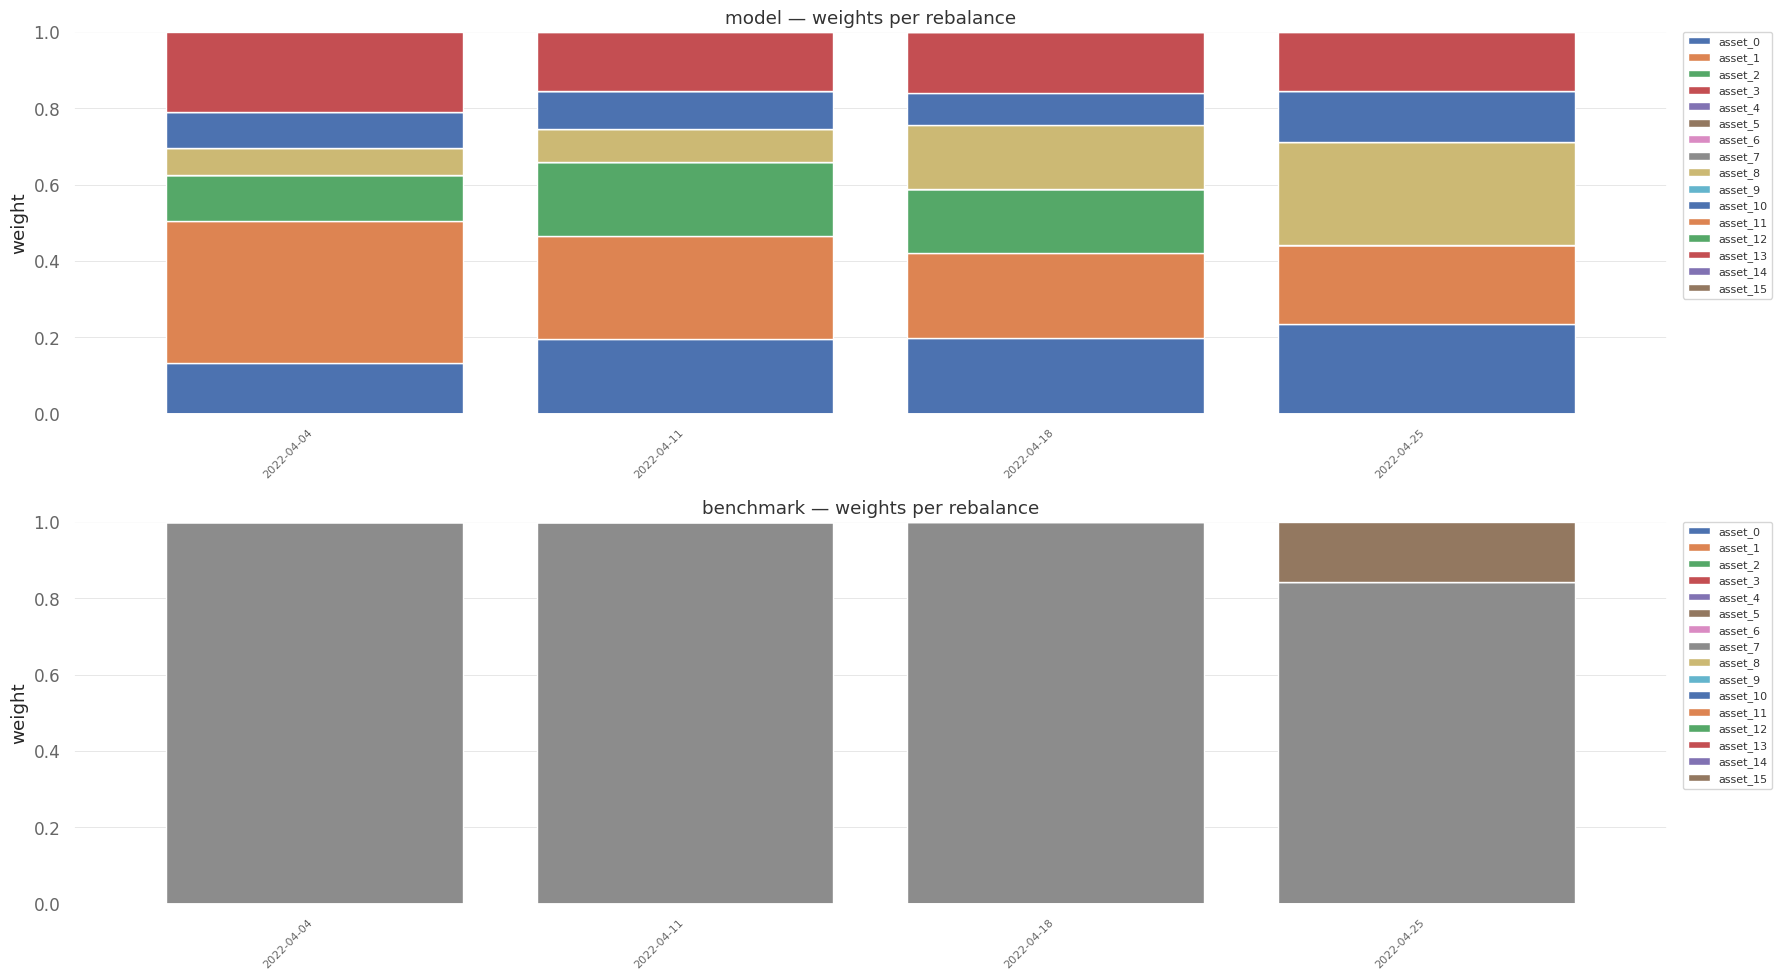

2026-05-28 03:47:04,931 - entities.portfolio - INFO - Strategy: model vs Benchmark: benchmark
2026-05-28 03:47:06,150 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:06,156 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:06,191 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:06,192 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:06,236 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:06,237 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:06,238 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:06,278 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:06,334 - matplotlib.font_manager - WARNING - findfont: Font famil

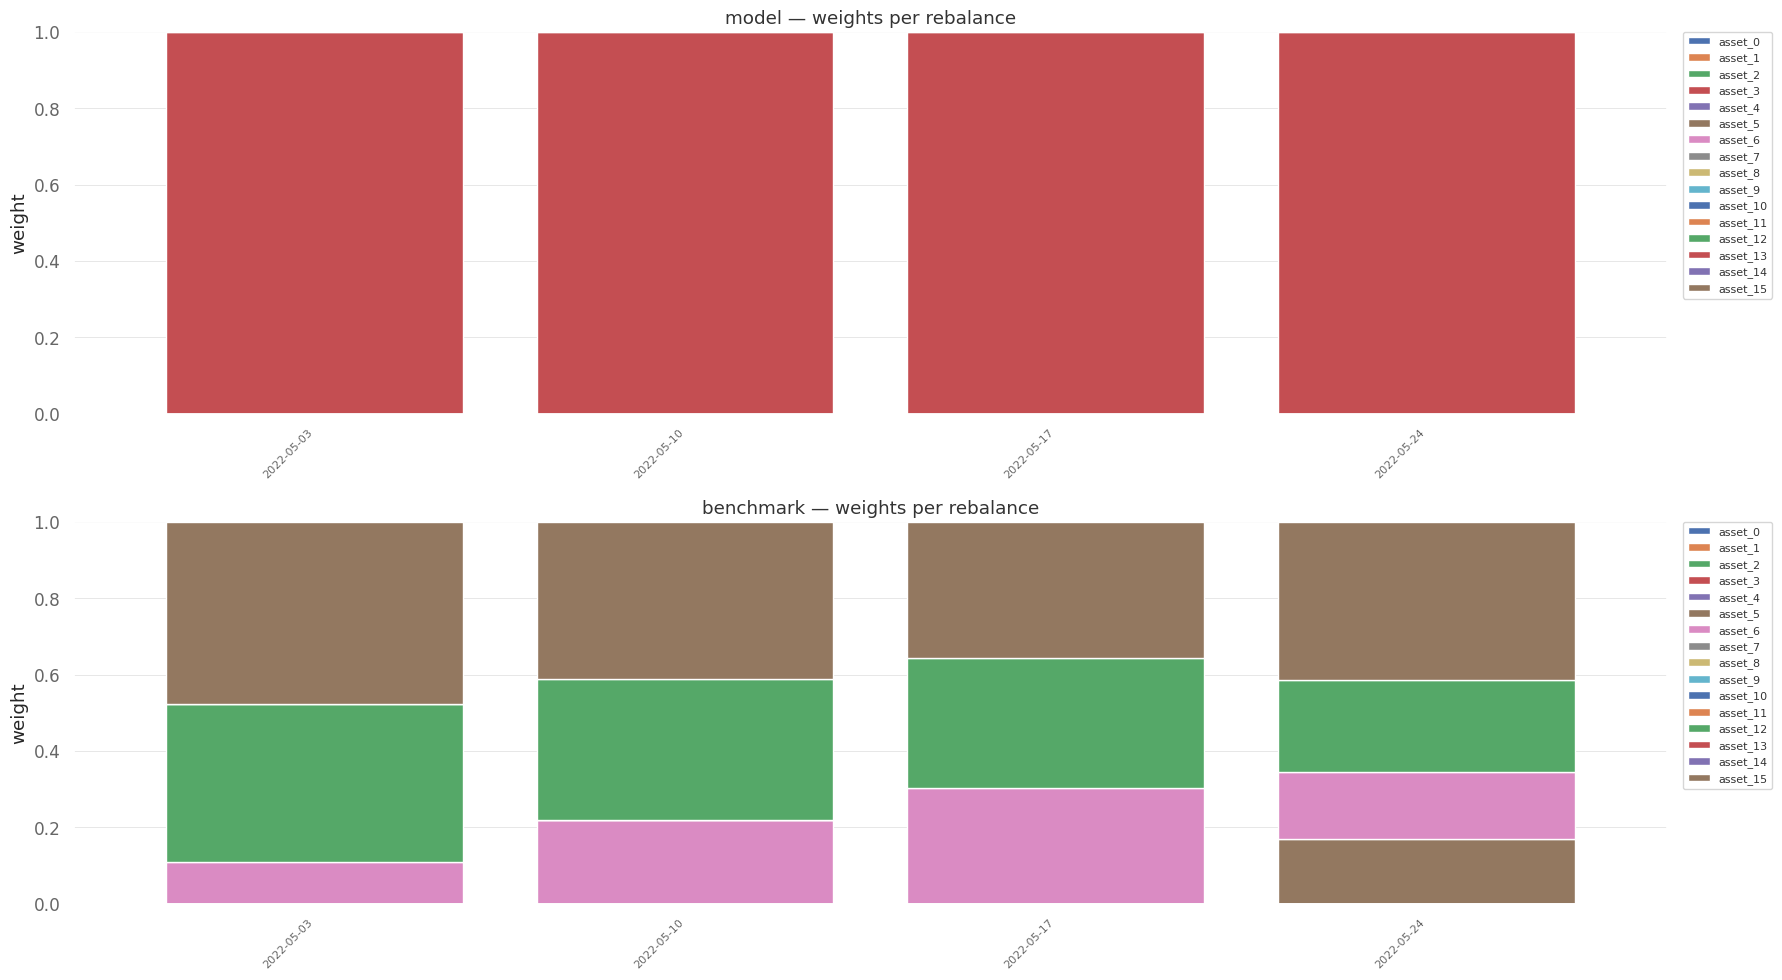

2026-05-28 03:47:22,838 - entities.portfolio - INFO - Strategy: model vs Benchmark: benchmark
2026-05-28 03:47:23,686 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:23,687 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:23,719 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:23,719 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:23,763 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:23,764 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:23,765 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:23,805 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:23,856 - matplotlib.font_manager - WARNING - findfont: Font famil

/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2323: RuntimeWarning:

invalid value encountered in multiply

/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2324: RuntimeWarning:

invalid value encountered in multiply



2026-05-28 03:47:35,275 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:35,276 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:35,278 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:35,320 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:35,374 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:35,375 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:35,408 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:35,409 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:35,451 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:35,452 - matplotlib.font_manager - WARNING - findfont: F

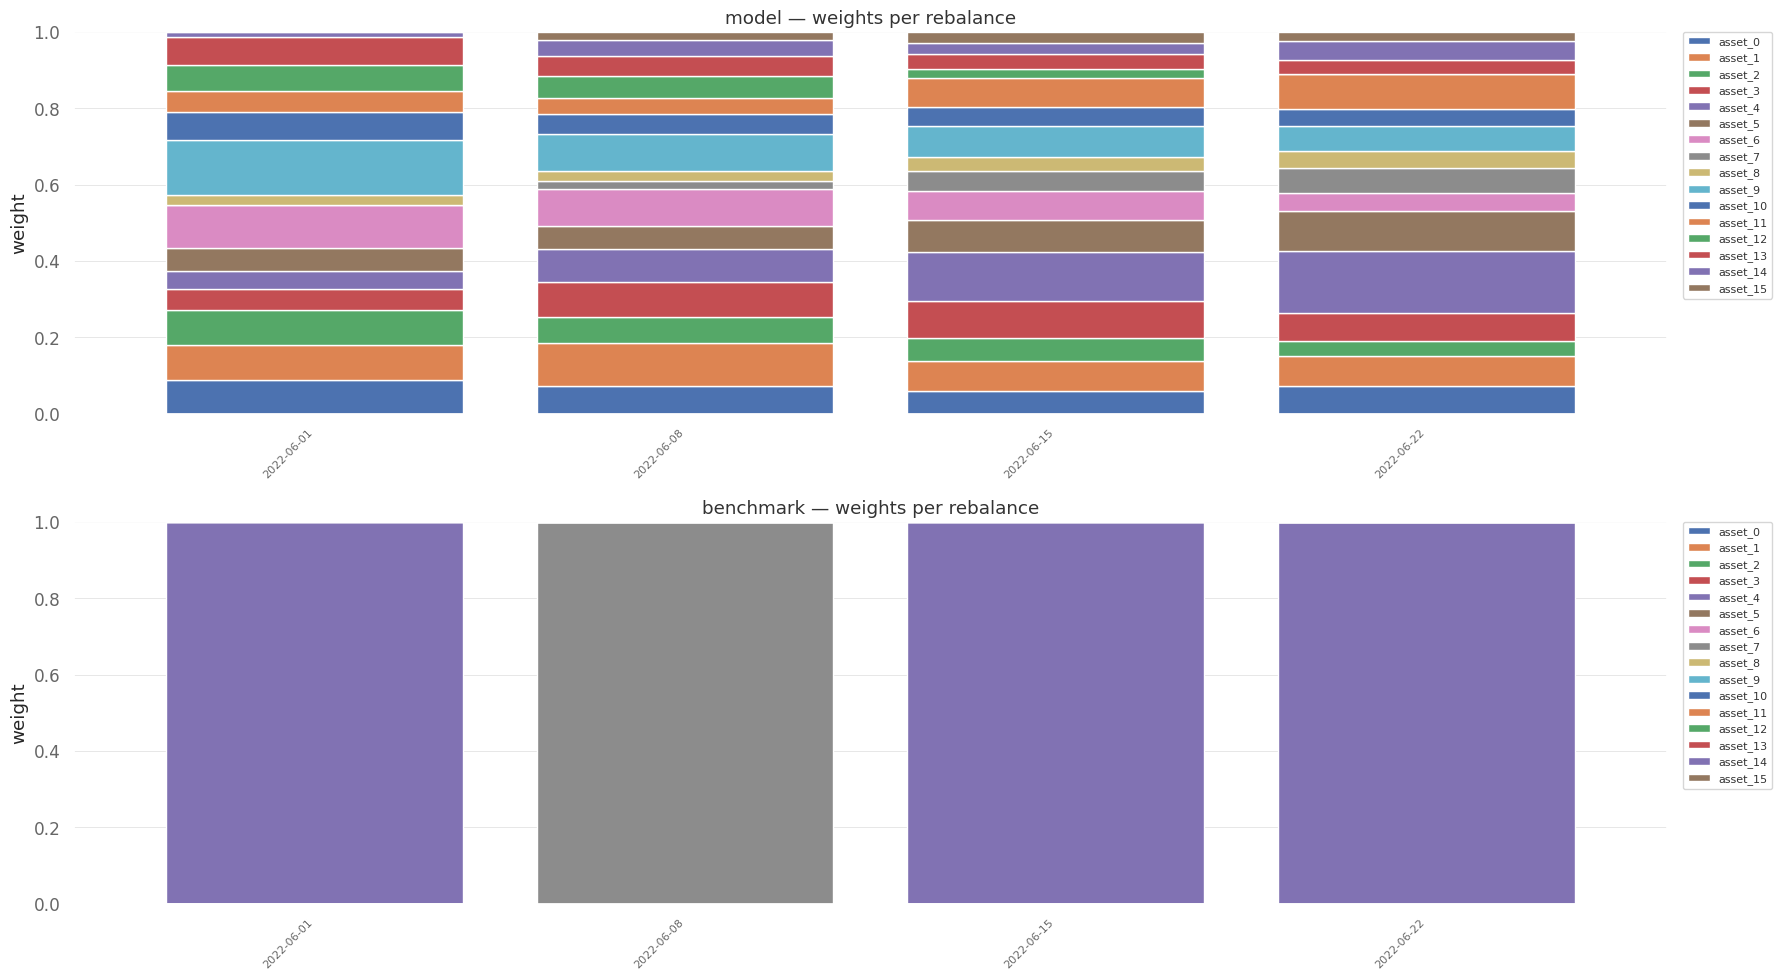

2026-05-28 03:47:39,747 - entities.portfolio - INFO - Strategy: model vs Benchmark: benchmark
2026-05-28 03:47:40,587 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:40,589 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:40,622 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:40,623 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:40,668 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:40,669 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:40,670 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:40,712 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:40,764 - matplotlib.font_manager - WARNING - findfont: Font famil

/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

invalid value encountered in sqrt



2026-05-28 03:47:44,037 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:44,038 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:44,072 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:44,073 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:44,118 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:44,118 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:44,120 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:44,161 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:44,217 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:44,218 - matplotlib.font_manager - WARNING - findfont: F

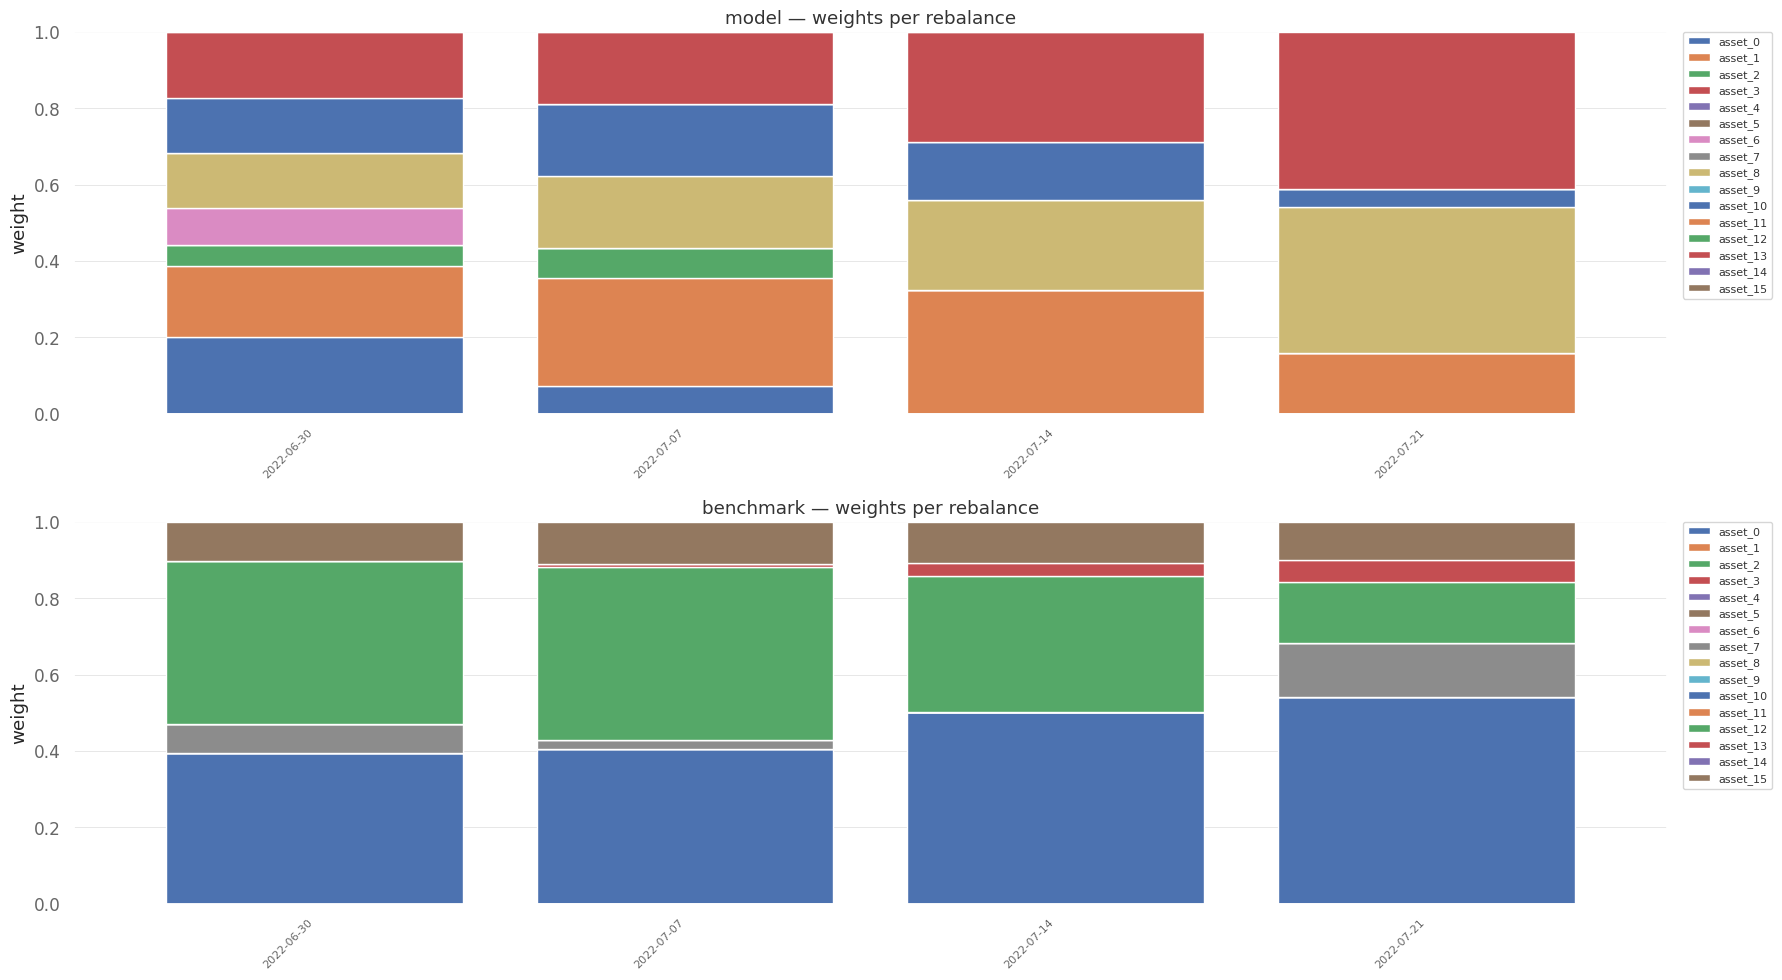

2026-05-28 03:47:56,197 - entities.portfolio - INFO - Strategy: model vs Benchmark: benchmark


/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

invalid value encountered in sqrt



2026-05-28 03:47:56,934 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:56,935 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:56,968 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:56,969 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:57,014 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:57,015 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:57,016 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:57,059 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:57,115 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:47:57,116 - matplotlib.font_manager - WARNING - findfont: F

/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2323: RuntimeWarning:

invalid value encountered in multiply

/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2324: RuntimeWarning:

invalid value encountered in multiply



2026-05-28 03:48:04,708 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:04,709 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:04,710 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:04,753 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:04,806 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:04,807 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:04,840 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:04,841 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:04,885 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:04,886 - matplotlib.font_manager - WARNING - findfont: F

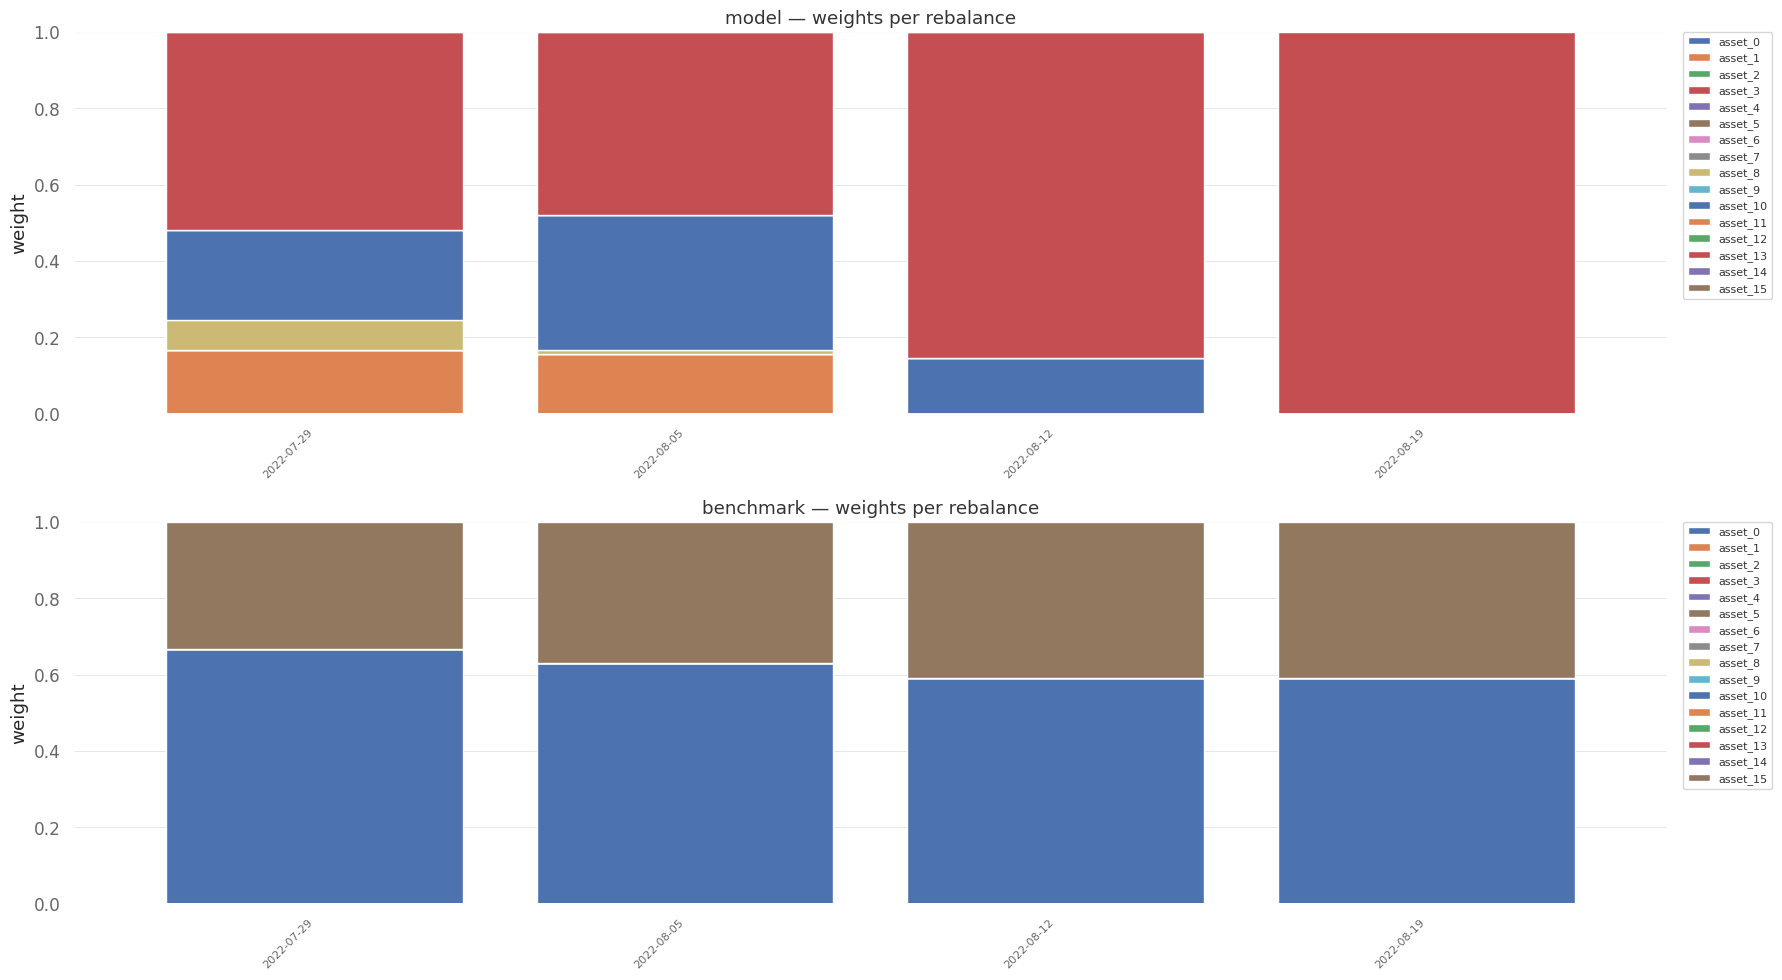

2026-05-28 03:48:12,903 - entities.portfolio - INFO - Strategy: model vs Benchmark: benchmark


/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

invalid value encountered in sqrt

/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2323: RuntimeWarning:

invalid value encountered in multiply

/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2324: RuntimeWarning:

invalid value encountered in multiply



2026-05-28 03:48:13,736 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:13,737 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:13,771 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:13,772 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:13,818 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:13,819 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:13,820 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:13,864 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:13,918 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:13,919 - matplotlib.font_manager - WARNING - findfont: F

/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

invalid value encountered in sqrt



2026-05-28 03:48:17,239 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:17,240 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:17,274 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:17,275 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:17,320 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.


/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2323: RuntimeWarning:

invalid value encountered in multiply

/home/narodom.y@FUSION.LAB/.conda/envs/tsgenai/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2324: RuntimeWarning:

invalid value encountered in multiply



2026-05-28 03:48:17,321 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:17,322 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:17,365 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:17,419 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:17,420 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:17,453 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:17,454 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:17,499 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:17,500 - matplotlib.font_manager - WARNING - findfont: Font family 'Arial' not found.
2026-05-28 03:48:17,502 - matplotlib.font_manager - WARNING - findfont: F

In [13]:
# ── Hyperparams ───────────────────────────────────────────────────────
import torch


REBALANCE_FREQ   = 5
OPTIMIZE_WINDOW  = 10
ANNUAL_RF        = 0.02
INIT_CASH        = 1.0
TRANSACTION_COST = 0.001

portfolio = Portfolio(annual_risk_free_rate=ANNUAL_RF)

# ── Loop ราย sim-window ───────────────────────────────────────────────
all_results = {}  # { window_idx: dict[strategy_name, PortfolioResult] }

for i, w in enumerate(all_windows):
    gt_ret_w, gt_price_w = prepare_gt([w])   # (W-1, A)
    mc_ret_w             = prepare_mc([w])   # (N, W-1, A) — จาก diffusion model

    # date range ของ window นี้
    dates_w   = pd.to_datetime(w["dates"], unit="ns" if w["dates"][0] > 1e15 else "ms")
    start_w   = dates_w[1].date()   # [1:] เพราะ diff ตัดแถวแรก
    end_w     = dates_w[-1].date()

    gt_tensor   = torch.tensor(gt_ret_w, dtype=torch.float32)
    mc_gbm_w    = simulate_mc_gbm(
        log_returns = gt_tensor,
        n_paths     = N_SIMS,
        horizon     = gt_ret_w.shape[0],   # W-1
    ).numpy()   # (N, W-1, A)

    strategies = {
        "model"    : mc_ret_w,
        "benchmark": mc_gbm_w,
    }

    results_w = portfolio.experiment(
        gt_returns         = gt_ret_w,
        gt_prices          = gt_price_w,
        strategies         = strategies,
        benchmark_strategy = "benchmark",
        rebalance_freq     = REBALANCE_FREQ,
        optimize_window    = OPTIMIZE_WINDOW,
        start_date         = start_w,
        end_date           = end_w,
        init_cash          = INIT_CASH,
        is_log_return      = True,
        transaction_cost   = TRANSACTION_COST,
        method             = "Per-Path",
        output_dir         = str(inf_cfg.simulation_dir / "reports"),
        output_suffix      = f"_w{i:02d}_rebal{REBALANCE_FREQ}_opt{OPTIMIZE_WINDOW}",
    )

    all_results[i] = results_w
    print(f"✓ window {i:02d} done")

print(f"\n✓ ทั้งหมด {len(all_results)} windows")

In [14]:
all_results

{0: {'model': PortfolioResult(returns=2022-04-04    0.029915
  2022-04-05   -0.030612
  2022-04-06   -0.031923
  2022-04-07   -0.000816
  2022-04-08   -0.019834
  2022-04-11   -0.028144
  2022-04-12    0.001161
  2022-04-13    0.021906
  2022-04-14   -0.016432
  2022-04-15    0.009115
  2022-04-18    0.021439
  2022-04-19   -0.028246
  2022-04-20   -0.021929
  2022-04-21   -0.030018
  2022-04-22    0.007409
  2022-04-25   -0.056177
  2022-04-26   -0.013067
  2022-04-27    0.072453
  2022-04-28   -0.056891
  Freq: B, dtype: float64, portfolio=<vectorbt.portfolio.base.Portfolio object at 0x74c9a053c910>, weights=             asset_0   asset_1       asset_2       asset_3       asset_4  \
  2022-04-04  0.133935  0.371387  1.191435e-01  3.980867e-17  1.869721e-17   
  2022-04-11  0.196767  0.267389  1.943456e-01  0.000000e+00  7.489381e-18   
  2022-04-18  0.199434  0.221218  1.687323e-01  5.727626e-17  2.951888e-17   
  2022-04-25  0.236064  0.206521  1.360800e-17  2.133680e-17  4.589037e-

In [15]:
print(f"{'strategy':<14} {'sim_win':>8} {'rebal_win':>10} {'init':>8} {'final':>8} {'P&L':>8} {'ret%':>8}")
print("─" * 70)

for win_idx, results_w in all_results.items():
    for name, result in results_w.items():
        for i, wpf in enumerate(result.window_portfolios):
            final   = float(wpf.final_value())
            pnl     = float(wpf.total_profit())
            ret_pct = (final / INIT_CASH - 1) * 100
            print(f"{name:<14} {win_idx:>8} {i+1:>10} {INIT_CASH:>8.2f} {final:>8.4f} {pnl:>8.4f} {ret_pct:>7.2f}%")

strategy        sim_win  rebal_win     init    final      P&L     ret%
──────────────────────────────────────────────────────────────────────
model                 0          1     1.00   0.9202  -0.0798   -7.98%
model                 0          2     1.00   1.0159   0.0159    1.59%
model                 0          3     1.00   0.9298  -0.0702   -7.02%
model                 0          4     1.00   1.0025   0.0025    0.25%
benchmark             0          1     1.00   1.0206   0.0206    2.06%
benchmark             0          2     1.00   1.0099   0.0099    0.99%
benchmark             0          3     1.00   1.0134   0.0134    1.34%
benchmark             0          4     1.00   0.9998  -0.0002   -0.02%
model                 1          1     1.00   0.8657  -0.1343  -13.43%
model                 1          2     1.00   0.9054  -0.0946   -9.46%
model                 1          3     1.00   0.8861  -0.1139  -11.39%
model                 1          4     1.00   1.2093   0.2093   20.93%
benchm

In [16]:
# print(f"{'strategy':<14} {'sim_win':>8} {'final':>8} {'P&L':>8} {'ret%':>8}")
# print("─" * 56)

# for win_idx, portfolios_w in all_results.items():
#     for name, pf in portfolios_w.items():
#         final   = float(pf.final_value())
#         pnl     = float(pf.total_profit())
#         ret_pct = (final / INIT_CASH - 1) * 100
#         print(f"{name:<14} {win_idx:>8} {INIT_CASH:>8.2f} {final:>8.4f} {pnl:>8.4f} {ret_pct:>7.2f}%")

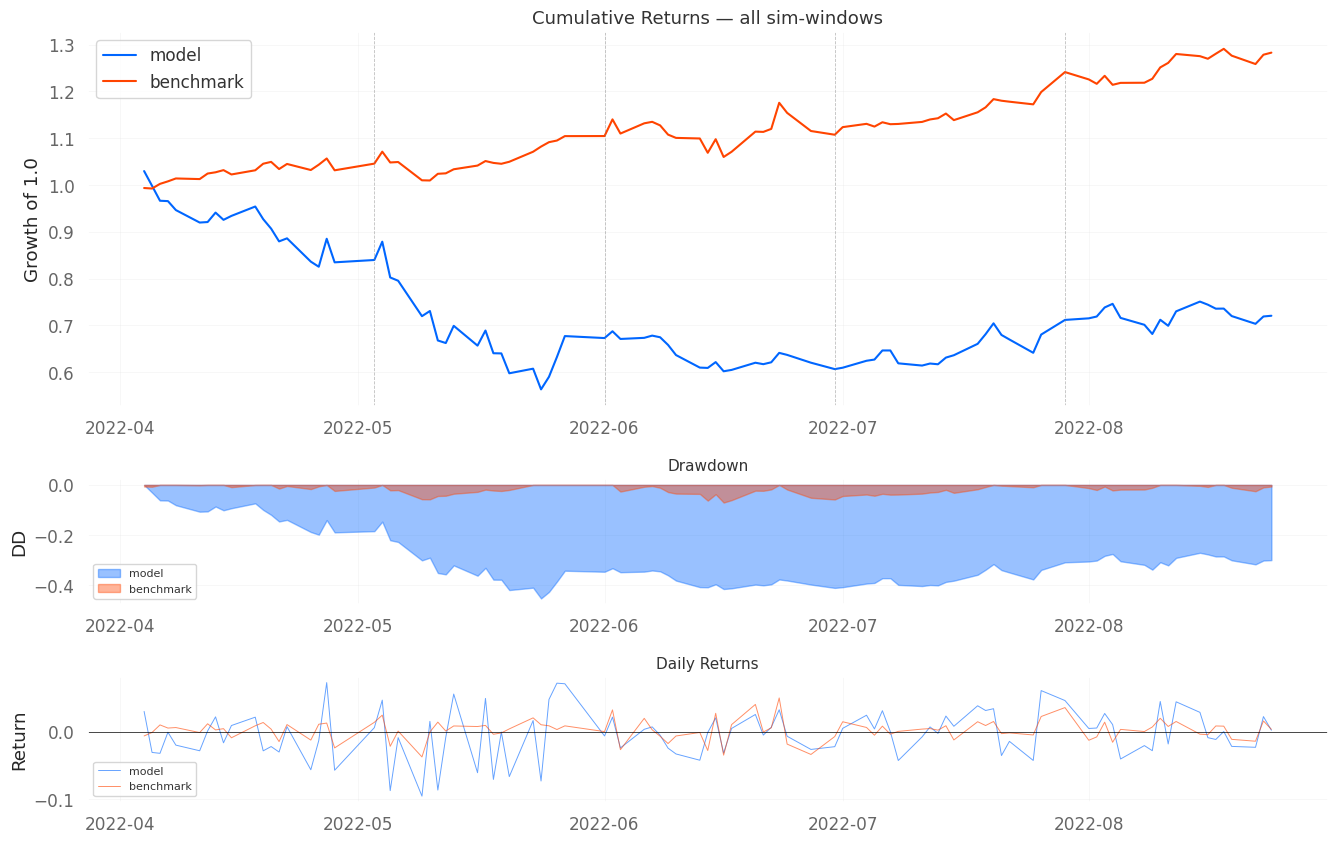


════════════════════════════════════════════════════════════
  Portfolio Stats (full period — all sim-windows concat)
════════════════════════════════════════════════════════════
          Cum. Ret. (%) Ann. Ret. (%)  Sharpe Sortino  Calmar Max DD (%) LDD (days)
Strategy                                                                           
model           -27.92%       -58.05%  -1.260  -1.640  -1.282    -45.29%         94
benchmark        28.30%        93.69%   2.892   4.581  13.303     -7.04%         16
════════════════════════════════════════════════════════════


In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import quantstats as qs
import pandas as pd
import numpy as np

# ── 1. Concat returns ราย strategy ข้าม sim-windows ─────────────────
strategy_names = list(next(iter(all_results.values())).keys())

concat_returns: dict[str, pd.Series] = {}
for name in strategy_names:
    parts = []
    for win_idx in sorted(all_results.keys()):
        parts.append(all_results[win_idx][name].returns)
    concat_returns[name] = pd.concat(parts)

# ── 2. Compute stats ─────────────────────────────────────────────────
def compute_stats(ret: pd.Series, rf: float) -> dict:
    cum = (1 + ret).cumprod()
    total_ret   = cum.iloc[-1] - 1
    ann_ret     = qs.stats.cagr(ret, rf=rf)
    sharpe      = qs.stats.sharpe(ret, rf=rf)
    sortino     = qs.stats.sortino(ret, rf=rf)
    max_dd      = qs.stats.max_drawdown(ret)
    calmar      = qs.stats.calmar(ret)

    # LDD — longest drawdown duration (in days)
    dd = qs.stats.to_drawdown_series(ret)
    in_dd = dd < 0
    max_consec = 0
    curr = 0
    for v in in_dd:
        curr = curr + 1 if v else 0
        max_consec = max(max_consec, curr)

    return {
        "Cum. Ret. (%)": f"{total_ret*100:.2f}%",
        "Ann. Ret. (%)": f"{ann_ret*100:.2f}%",
        "Sharpe":        f"{sharpe:.3f}",
        "Sortino":       f"{sortino:.3f}",
        "Calmar":        f"{calmar:.3f}",
        "Max DD (%)":    f"{max_dd*100:.2f}%",
        "LDD (days)":    f"{max_consec}",
    }

rf = portfolio.daily_risk_free_rate
stats_all = {name: compute_stats(concat_returns[name], rf) for name in strategy_names}

# ── 3. Plot ──────────────────────────────────────────────────────────
colors = {"model": "#0066FF", "benchmark": "#FF4400"}

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(3, 1, height_ratios=[3, 1, 1], hspace=0.35)

# --- Equity curve ---
ax_eq = fig.add_subplot(gs[0])
for name, ret in concat_returns.items():
    cum = (1 + ret).cumprod()
    ax_eq.plot(cum.index, cum.values, label=name, color=colors.get(name), linewidth=1.5)

# sim-window boundaries
window_dates = []
for win_idx in sorted(all_results.keys()):
    ret = next(iter(all_results[win_idx].values())).returns
    window_dates.append(ret.index[0])

for d in window_dates[1:]:
    ax_eq.axvline(d, color="gray", linewidth=0.6, linestyle="--", alpha=0.5)

ax_eq.set_title("Cumulative Returns — all sim-windows", fontsize=13)
ax_eq.set_ylabel("Growth of 1.0")
ax_eq.legend()
ax_eq.grid(alpha=0.3)

# --- Drawdown ---
ax_dd = fig.add_subplot(gs[1])
for name, ret in concat_returns.items():
    dd = qs.stats.to_drawdown_series(ret)
    ax_dd.fill_between(dd.index, dd.values, 0, alpha=0.4, label=name, color=colors.get(name))
ax_dd.set_title("Drawdown", fontsize=11)
ax_dd.set_ylabel("DD")
ax_dd.legend(fontsize=8)
ax_dd.grid(alpha=0.3)

# --- Daily returns ---
ax_ret = fig.add_subplot(gs[2])
for name, ret in concat_returns.items():
    ax_ret.plot(ret.index, ret.values, alpha=0.6, linewidth=0.7,
                label=name, color=colors.get(name))
ax_ret.axhline(0, color="black", linewidth=0.5)
ax_ret.set_title("Daily Returns", fontsize=11)
ax_ret.set_ylabel("Return")
ax_ret.legend(fontsize=8)
ax_ret.grid(alpha=0.3)

plt.savefig(str(inf_cfg.simulation_dir / "reports" / "equity_curve.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# ── 4. Stats table ───────────────────────────────────────────────────
stats_df = pd.DataFrame(stats_all).T
stats_df.index.name = "Strategy"
print("\n" + "═" * 60)
print("  Portfolio Stats (full period — all sim-windows concat)")
print("═" * 60)
print(stats_df.to_string())
print("═" * 60)